# Stock Time-Series EDA Notebook

This notebook is set up so you can:

- load the stock dataset once
- choose a ticker from a dropdown at the top
- see all summaries printed directly in the notebook output
- see all plots inline in the notebook

Nothing is saved to separate image files by default.


In [1]:

# Install once if needed:
# %pip install ipywidgets seaborn statsmodels matplotlib pandas pyarrow fastparquet

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets

from IPython.display import display, Markdown
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11


In [2]:

# -----------------------------
# DATA LOAD
# -----------------------------
# Option 1: if `df` is already in memory, this cell will use it.
# Option 2: otherwise update DATA_PATH to your local parquet/csv file and run.

DATA_PATH = Path("/content/TOP250_STOCKS_6Y_FINAL.parquet")  # change this if needed

if "df" not in globals():
    if DATA_PATH.exists():
        if DATA_PATH.suffix.lower() == ".parquet":
            df = pd.read_parquet(DATA_PATH)
        elif DATA_PATH.suffix.lower() == ".csv":
            df = pd.read_csv(DATA_PATH)
        else:
            raise ValueError(f"Unsupported file type: {DATA_PATH.suffix}")
    else:
        raise FileNotFoundError(
            f"Could not find dataset at {DATA_PATH}. "
            "Either change DATA_PATH or make sure `df` is already loaded in memory."
        )

print("Dataset loaded successfully")
print("Shape:", df.shape)
print("Date range:", pd.to_datetime(df["Date"]).min(), "to", pd.to_datetime(df["Date"]).max())
print("Unique tickers:", df["Ticker"].nunique())
display(df.head())


Dataset loaded successfully
Shape: (145303, 25)
Date range: 2020-04-14 00:00:00 to 2026-03-12 00:00:00
Unique tickers: 101


,Date,Ticker,Open,High,Low,Close,Adj_Close,Volume,SMA_20,EMA_20,...,volatility_20d,index_adj_close,index_close,index_high,index_low,index_open,index_volume,index_return,index_volatility,fed_rate
0,2020-04-14,A,77.300003,79.199997,77.239998,78.830002,75.764587,2650300.0,71.495001,72.198613,...,0.042550,2846.060059,2846.060059,2851.850098,2805.100098,2805.100098,5615730000,0.030573,0.041409,0.05
1,2020-04-15,A,77.440002,78.389999,77.000000,77.050003,74.053848,2721100.0,71.825501,72.660651,...,0.037843,2783.360107,2783.360107,2801.879883,2761.540039,2795.639893,5208000000,-0.022030,0.040208,0.05
2,2020-04-16,A,78.059998,78.919998,76.470001,78.750000,75.687714,1969300.0,72.319501,73.240589,...,0.037447,2799.550049,2799.550049,2806.510010,2764.320068,2799.340088,5228810000,0.005817,0.037876,0.05
3,2020-04-17,A,80.089996,80.349998,78.309998,79.550003,76.456612,1313400.0,73.009001,73.841485,...,0.035346,2874.560059,2874.560059,2879.219971,2830.879883,2842.429932,5804810000,0.026794,0.038083,0.05
4,2020-04-20,A,79.050003,79.050003,76.980003,77.370003,74.361374,1679400.0,73.554501,74.177534,...,0.036328,2823.159912,2823.159912,2868.979980,2820.429932,2845.620117,5228630000,-0.017881,0.036618,0.05


In [3]:


REQUIRED_COLS = [
    "Date", "Ticker", "Open", "High", "Low", "Close", "Adj_Close", "Volume",
    "SMA_20", "EMA_20", "RSI_14", "BB_Middle", "BB_Upper", "BB_Lower",
    "return_1d", "volatility_20d", "index_adj_close", "index_close",
    "index_high", "index_low", "index_open", "index_volume", "index_return",
    "index_volatility", "fed_rate"
]

missing_required = [c for c in REQUIRED_COLS if c not in df.columns]
if missing_required:
    print("Missing expected columns:", missing_required)
else:
    print("All expected columns are present.")

def prepare_stock_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["Date"] = pd.to_datetime(out["Date"], errors="coerce")
    out["Ticker"] = out["Ticker"].astype(str).str.upper().str.strip()

    numeric_cols = [
        "Open", "High", "Low", "Close", "Adj_Close", "Volume",
        "SMA_20", "EMA_20", "RSI_14", "BB_Middle", "BB_Upper", "BB_Lower",
        "return_1d", "volatility_20d",
        "index_adj_close", "index_close", "index_high", "index_low",
        "index_open", "index_volume", "index_return", "index_volatility",
        "fed_rate"
    ]
    for col in numeric_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    out = out.dropna(subset=["Date", "Ticker", "Adj_Close"]).copy()
    out = out.sort_values(["Ticker", "Date"]).reset_index(drop=True)

    out["cummax_price"] = out.groupby("Ticker")["Adj_Close"].cummax()
    out["drawdown"] = out["Adj_Close"] / out["cummax_price"] - 1.0
    out["Month"] = out["Date"].dt.strftime("%b")
    out["Weekday"] = out["Date"].dt.day_name()
    out["Year"] = out["Date"].dt.year
    return out

df_eda = prepare_stock_df(df)
print("Prepared dataset shape:", df_eda.shape)
display(df_eda.head())


All expected columns are present.
Prepared dataset shape: (145303, 30)


,Date,Ticker,Open,High,Low,Close,Adj_Close,Volume,SMA_20,EMA_20,...,index_open,index_volume,index_return,index_volatility,fed_rate,cummax_price,drawdown,Month,Weekday,Year
0,2020-04-14,A,77.300003,79.199997,77.239998,78.830002,75.764587,2650300.0,71.495001,72.198613,...,2805.100098,5615730000,0.030573,0.041409,0.05,75.764587,0.000000,Apr,Tuesday,2020
1,2020-04-15,A,77.440002,78.389999,77.000000,77.050003,74.053848,2721100.0,71.825501,72.660651,...,2795.639893,5208000000,-0.022030,0.040208,0.05,75.764587,-0.022580,Apr,Wednesday,2020
2,2020-04-16,A,78.059998,78.919998,76.470001,78.750000,75.687714,1969300.0,72.319501,73.240589,...,2799.340088,5228810000,0.005817,0.037876,0.05,75.764587,-0.001015,Apr,Thursday,2020
3,2020-04-17,A,80.089996,80.349998,78.309998,79.550003,76.456612,1313400.0,73.009001,73.841485,...,2842.429932,5804810000,0.026794,0.038083,0.05,76.456612,0.000000,Apr,Friday,2020
4,2020-04-20,A,79.050003,79.050003,76.980003,77.370003,74.361374,1679400.0,73.554501,74.177534,...,2845.620117,5228630000,-0.017881,0.036618,0.05,76.456612,-0.027404,Apr,Monday,2020


DATASET SUMMARY
Rows: 145303
Ticker count: 101
Start date: 2020-04-14 00:00:00
End date: 2026-03-12 00:00:00

Top 10 tickers by number of rows


,Ticker,start_date,end_date,rows,first_price,last_price,avg_return,volatility_mean,avg_volume,min_drawdown,avg_rsi,total_return
0,A,2020-04-14,2026-03-12,1486,75.764587,111.910004,0.000415,0.017121,1.762262e+06,-0.431929,52.305869,0.477075
1,AAPL,2020-04-14,2026-03-12,1486,69.358711,255.904999,0.001056,0.017204,7.824274e+07,-0.333605,54.464592,2.689587
2,ABBV,2020-04-14,2026-03-12,1486,65.345367,226.289993,0.000805,0.013905,6.444118e+06,-0.219155,53.907435,2.462984
3,ABT,2020-04-14,2026-03-12,1486,80.449966,108.599998,0.000264,0.013988,5.822125e+06,-0.338767,51.356396,0.349907
4,AD,2020-04-14,2026-03-12,1486,17.884548,48.009998,0.000881,0.027388,2.164806e+05,-0.642283,50.535555,1.684440
5,ADI,2020-04-14,2026-03-12,1486,92.709236,306.429993,0.000967,0.019762,3.443247e+06,-0.321975,53.219913,2.305280
6,AL,2020-04-14,2026-03-12,1486,21.834635,64.635002,0.000969,0.022510,9.433865e+05,-0.406116,52.675598,1.960205
7,AMAT,2020-04-14,2026-03-12,1486,49.673096,336.439911,0.001668,0.026813,7.250872e+06,-0.551392,53.815967,5.773081
8,AMD,2020-04-14,2026-03-12,1486,54.930000,198.250000,0.001466,0.031917,5.983424e+07,-0.654499,52.432928,2.609139
9,AMGN,2020-04-14,2026-03-12,1486,188.582169,369.992493,0.000473,0.014800,2.704672e+06,-0.248599,51.769440,0.961970



Missing values (%)


,missing_pct
Date,0.0
Ticker,0.0
Open,0.0
High,0.0
Low,0.0
Close,0.0
Adj_Close,0.0
Volume,0.0
SMA_20,0.0
EMA_20,0.0


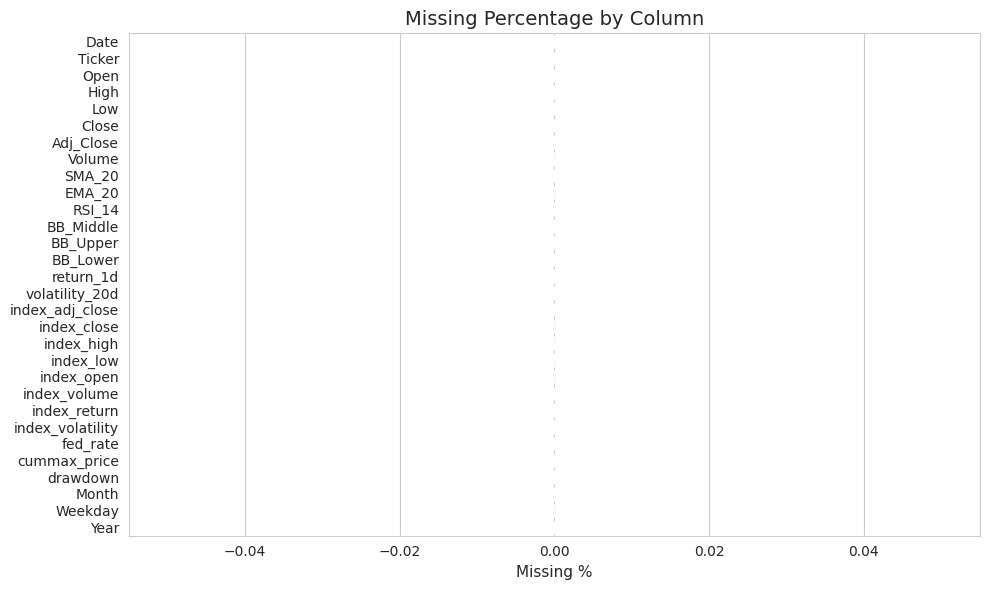

In [4]:

# OVERALL DATASET SUMMARY
def create_summary(df: pd.DataFrame) -> pd.DataFrame:
    summary = (
        df.groupby("Ticker")
        .agg(
            start_date=("Date", "min"),
            end_date=("Date", "max"),
            rows=("Date", "size"),
            first_price=("Adj_Close", "first"),
            last_price=("Adj_Close", "last"),
            avg_return=("return_1d", "mean"),
            volatility_mean=("volatility_20d", "mean"),
            avg_volume=("Volume", "mean"),
            min_drawdown=("drawdown", "min"),
            avg_rsi=("RSI_14", "mean"),
        )
        .reset_index()
    )
    summary["total_return"] = summary["last_price"] / summary["first_price"] - 1.0
    summary = summary.sort_values(["rows", "Ticker"], ascending=[False, True]).reset_index(drop=True)
    return summary

summary = create_summary(df_eda)

print("=" * 90)
print("DATASET SUMMARY")
print("=" * 90)
print("Rows:", len(df_eda))
print("Ticker count:", df_eda["Ticker"].nunique())
print("Start date:", df_eda["Date"].min())
print("End date:", df_eda["Date"].max())

print("\nTop 10 tickers by number of rows")
display(summary.head(10))

print("\nMissing values (%)")
missing_pct = df_eda.isna().mean().mul(100).sort_values(ascending=False).round(2)
display(missing_pct.to_frame("missing_pct"))

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_pct.values, y=missing_pct.index)
plt.title("Missing Percentage by Column")
plt.xlabel("Missing %")
plt.ylabel("")
plt.tight_layout()
plt.show()


In [5]:

# INTERACTIVE TICKER EDA
def render_ticker_eda(ticker: str):
    sdf = df_eda[df_eda["Ticker"] == ticker].copy().sort_values("Date")

    if sdf.empty:
        print(f"No data found for {ticker}")
        return

    print("=" * 90)
    print(f"EDA FOR TICKER: {ticker}")
    print("=" * 90)
    print("Rows:", len(sdf))
    print("Start date:", sdf["Date"].min())
    print("End date:", sdf["Date"].max())
    print("First Adj_Close:", round(float(sdf["Adj_Close"].iloc[0]), 4))
    print("Last Adj_Close:", round(float(sdf["Adj_Close"].iloc[-1]), 4))
    print("Total return (%):", round((float(sdf["Adj_Close"].iloc[-1]) / float(sdf["Adj_Close"].iloc[0]) - 1) * 100, 2))
    print("Average daily return (%):", round(float(sdf["return_1d"].mean() * 100), 4))
    print("Average volatility_20d:", round(float(sdf["volatility_20d"].mean()), 6))
    print("Minimum drawdown (%):", round(float(sdf["drawdown"].min() * 100), 2))
    print("Average RSI_14:", round(float(sdf["RSI_14"].mean()), 2))

    print("\nLast 5 rows")
    display(sdf.tail())

    if sdf["Adj_Close"].iloc[0] != 0:
        sdf["stock_indexed"] = sdf["Adj_Close"] / sdf["Adj_Close"].iloc[0] * 100
    else:
        sdf["stock_indexed"] = sdf["Adj_Close"]

    if sdf["index_adj_close"].notna().sum() > 0 and pd.notna(sdf["index_adj_close"].iloc[0]) and sdf["index_adj_close"].iloc[0] != 0:
        sdf["market_indexed"] = sdf["index_adj_close"] / sdf["index_adj_close"].iloc[0] * 100
    else:
        sdf["market_indexed"] = np.nan

    # ---- Main grid of plots ----
    fig, axes = plt.subplots(5, 2, figsize=(22, 28))
    axes = axes.flatten()

    axes[0].plot(sdf["Date"], sdf["Adj_Close"], label="Adj_Close", linewidth=2)
    axes[0].plot(sdf["Date"], sdf["SMA_20"], label="SMA_20", linestyle="--")
    axes[0].plot(sdf["Date"], sdf["EMA_20"], label="EMA_20", linestyle=":")
    axes[0].set_title(f"{ticker} Price with SMA_20 and EMA_20")
    axes[0].legend()

    axes[1].plot(sdf["Date"], sdf["Adj_Close"], label="Adj_Close", linewidth=2)
    axes[1].plot(sdf["Date"], sdf["BB_Middle"], label="BB_Middle", linestyle="--")
    axes[1].plot(sdf["Date"], sdf["BB_Upper"], label="BB_Upper", linestyle=":")
    axes[1].plot(sdf["Date"], sdf["BB_Lower"], label="BB_Lower", linestyle=":")
    axes[1].fill_between(sdf["Date"], sdf["BB_Lower"], sdf["BB_Upper"], alpha=0.2)
    axes[1].set_title(f"{ticker} Bollinger Bands")
    axes[1].legend()

    axes[2].bar(sdf["Date"], sdf["Volume"])
    axes[2].set_title(f"{ticker} Volume")

    axes[3].plot(sdf["Date"], sdf["return_1d"])
    axes[3].axhline(0, color="black", linewidth=1)
    axes[3].set_title(f"{ticker} Daily Return")

    sns.histplot(sdf["return_1d"].dropna(), bins=50, kde=True, ax=axes[4])
    axes[4].set_title(f"{ticker} Return Distribution")

    axes[5].plot(sdf["Date"], sdf["volatility_20d"])
    axes[5].set_title(f"{ticker} 20-Day Volatility")

    axes[6].plot(sdf["Date"], sdf["RSI_14"])
    axes[6].axhline(70, linestyle="--")
    axes[6].axhline(30, linestyle="--")
    axes[6].set_title(f"{ticker} RSI_14")

    axes[7].fill_between(sdf["Date"], sdf["drawdown"].fillna(0), 0, alpha=0.4)
    axes[7].set_title(f"{ticker} Drawdown")

    axes[8].plot(sdf["Date"], sdf["stock_indexed"], label=f"{ticker} Indexed")
    if sdf["market_indexed"].notna().sum() > 0:
        axes[8].plot(sdf["Date"], sdf["market_indexed"], label="Market Indexed")
    axes[8].set_title(f"{ticker} vs Market (Indexed to 100)")
    axes[8].legend()

    ax1 = axes[9]
    ax1.plot(sdf["Date"], sdf["Adj_Close"], label="Adj_Close")
    ax1.set_title(f"{ticker} Price vs Fed Rate")
    ax1.set_ylabel("Adj_Close")
    ax2 = ax1.twinx()
    ax2.plot(sdf["Date"], sdf["fed_rate"], linestyle="--")
    ax2.set_ylabel("Fed Rate")

    plt.tight_layout()
    plt.show()

    # ---- ACF / PACF ----
    ret = sdf["return_1d"].dropna()
    if len(ret) > 20:
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        plot_acf(ret, lags=min(30, len(ret)//2), ax=axes[0])
        plot_pacf(ret, lags=min(30, len(ret)//2), ax=axes[1], method="ywm")
        axes[0].set_title(f"{ticker} ACF of Returns")
        axes[1].set_title(f"{ticker} PACF of Returns")
        plt.tight_layout()
        plt.show()

    # ---- Correlation heatmap ----
    corr_cols = [
        "Adj_Close", "Volume", "SMA_20", "EMA_20", "RSI_14",
        "return_1d", "volatility_20d", "index_adj_close",
        "index_return", "index_volatility", "fed_rate"
    ]
    corr_cols = [c for c in corr_cols if c in sdf.columns]
    corr_df = sdf[corr_cols].dropna()

    if not corr_df.empty:
        plt.figure(figsize=(11, 8))
        sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
        plt.title(f"{ticker} Feature Correlation Heatmap")
        plt.tight_layout()
        plt.show()


In [6]:

ticker_options = sorted(df_eda["Ticker"].dropna().unique().tolist())
default_ticker = "AAPL" if "AAPL" in ticker_options else ticker_options[0]

ticker_dropdown = widgets.Dropdown(
    options=ticker_options,
    value=default_ticker,
    description="Ticker:",
    layout=widgets.Layout(width="350px")
)

ui = widgets.VBox([ticker_dropdown])
out = widgets.interactive_output(render_ticker_eda, {"ticker": ticker_dropdown})

display(ui, out)


Output()

## Quick notes

- Change the ticker from the dropdown at the top.
- All summaries are printed directly below the widget.
- All plots are shown inline in the notebook.
- Nothing is written to separate files in this version.
